# 03 — Segment Evaluation and Launch Recommendation

Breaks every recommender down by user segment and restaurant popularity tier, then checks cold-start failure and popularity bias. The conclusion is a launch rule, not only a leaderboard.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..", "src").resolve()))

import json
import matplotlib.pyplot as plt
import pandas as pd

from recsys.build_data import BUSINESS_PARQUET
from recsys.engine import build_connection
from recsys.evaluate import rmse

ROOT = Path("..").resolve()
OUTPUTS = ROOT / "outputs"
FIGURES = ROOT / "reports" / "figures"

predictions = pd.read_parquet(OUTPUTS / "test_predictions.parquet")
recommendations = pd.read_parquet(OUTPUTS / "recommendations.parquet")
item_lookup = pd.read_parquet(OUTPUTS / "item_lookup.parquet")
user_lookup = pd.read_parquet(OUTPUTS / "user_lookup.parquet")
model_metrics = pd.read_csv(OUTPUTS / "model_metrics.csv")
business = pd.read_parquet(BUSINESS_PARQUET)
con = build_connection()
user_segments = con.sql("SELECT user_id, user_segment FROM user_segments").df()
restaurant_segments = con.sql("SELECT business_id, popularity_tier FROM restaurant_segments").df()


In [2]:
pred = predictions.merge(user_segments, on="user_id", how="left")
pred = pred.merge(restaurant_segments, on="business_id", how="left")
recs = recommendations.merge(user_lookup, on="user_idx", how="left")
recs = recs.merge(item_lookup, on="item_idx", how="left")
recs = recs.merge(user_segments, on="user_id", how="left")
recs = recs.merge(restaurant_segments, on="business_id", how="left")
models = model_metrics["model"].tolist()


## Metrics by User Segment

For each segment, RMSE is computed on that segment's test rows. Hit rate@10 is row-based here: did the model's top-10 list for that user include the held-out restaurant? Coverage is the share of the full catalog recommended at least once to users in the segment.

In [3]:
user_rows = []
for model in models:
    hit_pairs = recs.loc[recs["model"] == model, ["user_idx", "item_idx"]].drop_duplicates()
    hit_pairs[f"hit_{model}"] = 1
    scored = pred.merge(hit_pairs, on=["user_idx", "item_idx"], how="left")
    scored[f"hit_{model}"] = scored[f"hit_{model}"].fillna(0)
    for segment, group in scored.groupby("user_segment"):
        segment_recs = recs[(recs["model"] == model) & (recs["user_segment"] == segment)]
        user_rows.append(
            {
                "model": model,
                "user_segment": segment,
                "n_test_reviews": int(len(group)),
                "rmse": rmse(group["y_true"].to_numpy(), group[f"pred_{model}"].to_numpy()),
                "hit_rate_at_10": float(group[f"hit_{model}"].mean()),
                "coverage": float(segment_recs["item_idx"].nunique() / item_lookup["item_idx"].nunique()),
            }
        )
user_segment_metrics = pd.DataFrame(user_rows).sort_values(["user_segment", "model"])
user_segment_metrics


,model,user_segment,n_test_reviews,rmse,hit_rate_at_10,coverage
4,Item-item CF,casual,3627,1.425547,0.000000,0.027561
0,Matrix factorization,casual,3627,1.388039,0.000276,0.002927
2,Popularity,casual,3627,1.425267,0.000000,0.017927
5,Item-item CF,power,9905,1.270579,0.000000,0.047439
1,Matrix factorization,power,9905,1.143948,0.000303,0.011220
3,Popularity,power,9905,1.247595,0.000000,0.033049


## Metrics by Restaurant Popularity Tier

In [4]:
tier_rows = []
for model in models:
    hit_pairs = recs.loc[recs["model"] == model, ["user_idx", "item_idx"]].drop_duplicates()
    hit_pairs[f"hit_{model}"] = 1
    scored = pred.merge(hit_pairs, on=["user_idx", "item_idx"], how="left")
    scored[f"hit_{model}"] = scored[f"hit_{model}"].fillna(0)
    for tier, group in scored.groupby("popularity_tier"):
        tier_catalog = restaurant_segments.loc[restaurant_segments["popularity_tier"] == tier, "business_id"]
        tier_recs = recs[(recs["model"] == model) & (recs["popularity_tier"] == tier)]
        tier_rows.append(
            {
                "model": model,
                "popularity_tier": tier,
                "n_test_reviews": int(len(group)),
                "rmse": rmse(group["y_true"].to_numpy(), group[f"pred_{model}"].to_numpy()),
                "hit_rate_at_10": float(group[f"hit_{model}"].mean()),
                "coverage": float(tier_recs["business_id"].nunique() / tier_catalog.nunique()),
            }
        )
restaurant_tier_metrics = pd.DataFrame(tier_rows).sort_values(["popularity_tier", "model"])
restaurant_tier_metrics


,model,popularity_tier,n_test_reviews,rmse,hit_rate_at_10,coverage
6,Item-item CF,high,8485,1.219854,0.000000,0.020246
0,Matrix factorization,high,8485,1.135485,0.000471,0.015184
3,Popularity,high,8485,1.195779,0.000000,0.008315
7,Item-item CF,low,639,1.587467,0.000000,0.025765
1,Matrix factorization,low,639,1.434593,0.000000,0.004371
4,Popularity,low,639,1.588733,0.000000,0.019324
8,Item-item CF,medium,4408,1.438761,0.000000,0.054812
2,Matrix factorization,medium,4408,1.321227,0.000000,0.005608
5,Popularity,medium,4408,1.432022,0.000000,0.037627


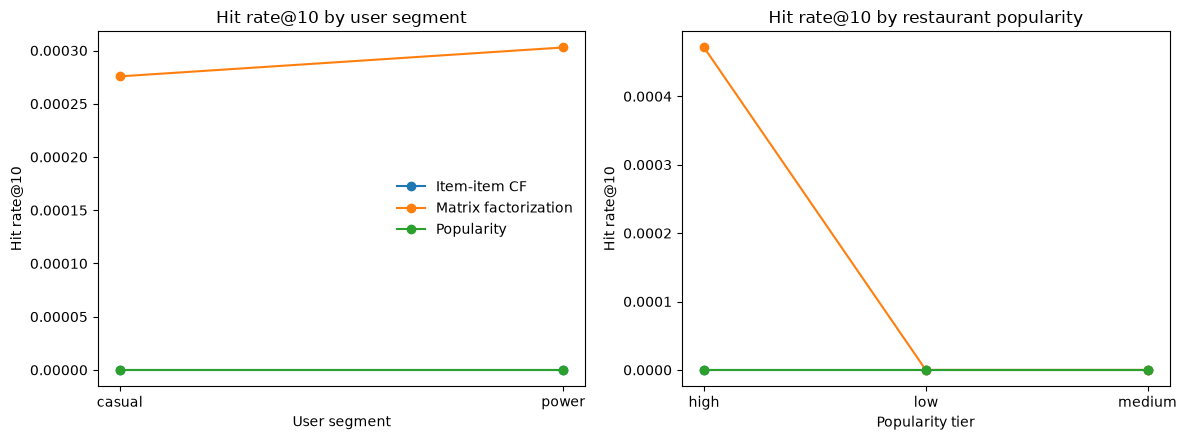

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for model, group in user_segment_metrics.groupby("model"):
    axes[0].plot(group["user_segment"], group["hit_rate_at_10"], marker="o", label=model)
axes[0].set_title("Hit rate@10 by user segment")
axes[0].set_xlabel("User segment")
axes[0].set_ylabel("Hit rate@10")
axes[0].legend(frameon=False)
for model, group in restaurant_tier_metrics.groupby("model"):
    axes[1].plot(group["popularity_tier"], group["hit_rate_at_10"], marker="o", label=model)
axes[1].set_title("Hit rate@10 by restaurant popularity")
axes[1].set_xlabel("Popularity tier")
axes[1].set_ylabel("Hit rate@10")
fig.tight_layout()
fig.savefig(FIGURES / "segment_hit_rate.png", dpi=160)
plt.show()


## Cold-Start Failure Analysis

Rows where the user or restaurant has no training-history are structural cold starts. Personalized models should fall back when user history is missing; item history gaps are handled best by popularity/content-like defaults.

In [6]:
cold = pred.copy()
cold["cold_start_group"] = "warm"
cold.loc[cold["user_train_count"].eq(0), "cold_start_group"] = "new user"
cold.loc[cold["item_train_count"].eq(0), "cold_start_group"] = "new restaurant"
cold.loc[cold["user_train_count"].eq(0) & cold["item_train_count"].eq(0), "cold_start_group"] = "new user + new restaurant"

cold_rows = []
for model in models:
    for group_name, group in cold.groupby("cold_start_group"):
        cold_rows.append(
            {
                "model": model,
                "cold_start_group": group_name,
                "n_test_reviews": int(len(group)),
                "rmse": rmse(group["y_true"].to_numpy(), group[f"pred_{model}"].to_numpy()),
            }
        )
cold_start_metrics = pd.DataFrame(cold_rows).sort_values(["cold_start_group", "model"])
cold_start_metrics


,model,cold_start_group,n_test_reviews,rmse
8,Item-item CF,new restaurant,2008,1.301783
0,Matrix factorization,new restaurant,2008,1.286950
4,Popularity,new restaurant,2008,1.301783
9,Item-item CF,new user,2132,1.242788
1,Matrix factorization,new user,2132,1.242788
5,Popularity,new user,2132,1.242788
10,Item-item CF,new user + new restaurant,333,1.267331
2,Matrix factorization,new user + new restaurant,333,1.267331
6,Popularity,new user + new restaurant,333,1.267331
11,Item-item CF,warm,9059,1.334393


## Popularity Bias

This check asks what share of recommendation slots go to the top 10% most-reviewed restaurants. A recommender can score well while narrowing discovery if it over-concentrates recommendations on already-popular places.

In [7]:
top_count_threshold = business["review_count"].quantile(0.9)
top_business_ids = set(business.loc[business["review_count"] >= top_count_threshold, "business_id"])
pop_bias = (
    recs.assign(is_top_10_pct_restaurant=recs["business_id"].isin(top_business_ids))
    .groupby("model", as_index=False)
    .agg(
        recommendation_slots=("business_id", "size"),
        share_to_top_10_pct_restaurants=("is_top_10_pct_restaurant", "mean"),
    )
    .sort_values("share_to_top_10_pct_restaurants", ascending=False)
)
pop_bias


,model,recommendation_slots,share_to_top_10_pct_restaurants
1,Matrix factorization,1000,0.723
0,Item-item CF,1000,0.008
2,Popularity,1000,0.000


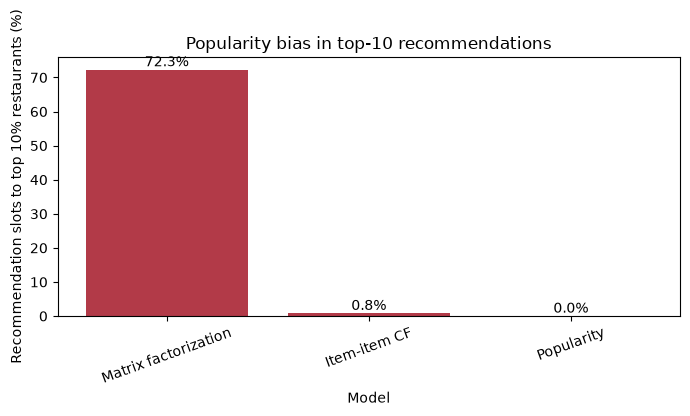

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(pop_bias["model"], pop_bias["share_to_top_10_pct_restaurants"] * 100, color="#B23A48")
ax.set_title("Popularity bias in top-10 recommendations")
ax.set_xlabel("Model")
ax.set_ylabel("Recommendation slots to top 10% restaurants (%)")
ax.tick_params(axis="x", rotation=20)
for i, row in pop_bias.reset_index(drop=True).iterrows():
    ax.text(i, row["share_to_top_10_pct_restaurants"] * 100 + 1, f"{row['share_to_top_10_pct_restaurants'] * 100:.1f}%", ha="center")
fig.tight_layout()
fig.savefig(FIGURES / "popularity_bias.png", dpi=160)
plt.show()


## Launch Decision

Ship the model that wins on hit rate@10 while keeping acceptable coverage. Use the popularity baseline as a fallback when a user has no history; that fallback is simple, stable, and transparent for cold start.

In [9]:
best = model_metrics.sort_values(["hit_rate_at_10", "coverage", "rmse"], ascending=[False, False, True]).iloc[0]
popularity = model_metrics.loc[model_metrics["model"] == "Popularity"].iloc[0]
new_user_rows = int(cold.loc[cold["user_train_count"].eq(0)].shape[0])
new_item_rows = int(cold.loc[cold["item_train_count"].eq(0)].shape[0])
launch_summary = {
    "ship_model": str(best["model"]),
    "ship_hit_rate_at_10": round(float(best["hit_rate_at_10"]), 4),
    "ship_rmse": round(float(best["rmse"]), 4),
    "ship_coverage": round(float(best["coverage"]), 4),
    "fallback_model": "Popularity",
    "fallback_hit_rate_at_10": round(float(popularity["hit_rate_at_10"]), 4),
    "fallback_rmse": round(float(popularity["rmse"]), 4),
    "new_user_test_reviews": new_user_rows,
    "new_restaurant_test_reviews": new_item_rows,
    "top_10_pct_threshold_review_count": int(top_count_threshold),
    "ship_share_to_top_10_pct_restaurants": round(
        float(pop_bias.loc[pop_bias["model"] == best["model"], "share_to_top_10_pct_restaurants"].iloc[0]), 4
    ),
}
user_segment_metrics.to_csv(OUTPUTS / "user_segment_metrics.csv", index=False)
restaurant_tier_metrics.to_csv(OUTPUTS / "restaurant_tier_metrics.csv", index=False)
cold_start_metrics.to_csv(OUTPUTS / "cold_start_metrics.csv", index=False)
pop_bias.to_csv(OUTPUTS / "popularity_bias.csv", index=False)
(OUTPUTS / "launch_summary.json").write_text(json.dumps(launch_summary, indent=2))
launch_summary


{'ship_model': 'Matrix factorization',
 'ship_hit_rate_at_10': 0.03,
 'ship_rmse': 1.2142,
 'ship_coverage': 0.0112,
 'fallback_model': 'Popularity',
 'fallback_hit_rate_at_10': 0.0,
 'fallback_rmse': 1.2976,
 'new_user_test_reviews': 2465,
 'new_restaurant_test_reviews': 2341,
 'top_10_pct_threshold_review_count': 195,
 'ship_share_to_top_10_pct_restaurants': 0.723}